In [ ]:
%pip install jupysql duckdb-engine --quiet

In [1]:
%load_ext sql
%config SqlMagic.autopandas = True  # Automatically convert query results to pandas dataframes
%sql duckdb://

Connecting to 'duckdb://'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('NCD_RisC_Nature_2020_Cholesterol_age_specific_countries_sql.csv').reset_index(drop = True)
#df

In [4]:
%%sql
drop table if exists temp_a;
create table temp_a
as select * 
from 'NCD_RisC_Nature_2020_Cholesterol_age_specific_countries_sql.csv';
select * 
from temp_a
limit 5

Running query in 'duckdb://'

,Country,Year,Gender,Age_group,Mean_total_cholesterol_mmolL,Mean_total_cholesterol_lower_95_percent_uncertainty_interval_mmolL,Mean_total_cholesterol_upper_95_percent_uncertainty_interval_mmolL,Mean_non_HDL_cholesterol_mmolL,Mean_non_HDL_cholesterol_lower_95_percent_uncertainty_interval_mmolL,Mean_non_HDL_cholesterol_upper_95_percent_uncertainty_interval_mmolL,Mean_HDL_cholesterol_mmolL,Mean_HDL_cholesterol_lower_95_percent_uncertainty_interval_mmolL,Mean_HDL_cholesterol_upper_95_percent_uncertainty_interval_mmolL
0,Afghanistan,1980,Men,18-19,3.938280,3.408243,4.450841,2.390296,1.786243,3.001487,1.203759,0.903827,1.491221
1,Afghanistan,1980,Men,20-24,4.030348,3.461665,4.583069,2.565352,2.025941,3.104508,1.207433,0.912178,1.486294
2,Afghanistan,1980,Men,25-29,4.152129,3.523245,4.771284,2.781679,2.317325,3.244324,1.209319,0.917293,1.482287
3,Afghanistan,1980,Men,30-34,4.257240,3.571934,4.923948,2.955077,2.523206,3.386726,1.209177,0.918113,1.481715
4,Afghanistan,1980,Men,35-39,4.339896,3.612904,5.052363,3.081967,2.652806,3.506228,1.209154,0.917683,1.481755


In [5]:
df = %sql select * from temp_a

Running query in 'duckdb://'

In [6]:
%%sql
drop table if exists temp_hungary;
create table temp_hungary
as select * 
from temp_a
where Country = 'Hungary';
select *
from temp_hungary

Running query in 'duckdb://'

,Country,Year,Gender,Age_group,Mean_total_cholesterol_mmolL,Mean_total_cholesterol_lower_95_percent_uncertainty_interval_mmolL,Mean_total_cholesterol_upper_95_percent_uncertainty_interval_mmolL,Mean_non_HDL_cholesterol_mmolL,Mean_non_HDL_cholesterol_lower_95_percent_uncertainty_interval_mmolL,Mean_non_HDL_cholesterol_upper_95_percent_uncertainty_interval_mmolL,Mean_HDL_cholesterol_mmolL,Mean_HDL_cholesterol_lower_95_percent_uncertainty_interval_mmolL,Mean_HDL_cholesterol_upper_95_percent_uncertainty_interval_mmolL
0,Hungary,1980,Men,18-19,4.636125,4.334383,4.939539,3.381302,3.136212,3.635506,1.270544,1.129363,1.414921
1,Hungary,1980,Men,20-24,4.942271,4.642705,5.239060,3.683149,3.472423,3.898785,1.277581,1.140410,1.417128
2,Hungary,1980,Men,25-29,5.304978,4.995532,5.614808,4.043971,3.845740,4.241874,1.283227,1.149580,1.420018
3,Hungary,1980,Men,30-34,5.585932,5.251845,5.914975,4.325666,4.124217,4.525721,1.285695,1.152352,1.421392
4,Hungary,1980,Men,35-39,5.791876,5.440048,6.140846,4.532323,4.321021,4.745695,1.287219,1.153418,1.423273
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1165,Hungary,2018,Women,65-69,5.477678,4.761396,6.188054,3.806355,3.408450,4.213392,1.528288,1.315015,1.756245
1166,Hungary,2018,Women,70-74,5.371617,4.644932,6.100454,3.675172,3.247639,4.109959,1.525294,1.313895,1.749127
1167,Hungary,2018,Women,75-79,5.271146,4.521672,6.016035,3.555521,3.098083,4.012658,1.528061,1.317843,1.751792
1168,Hungary,2018,Women,80-84,5.230705,4.445652,6.024696,3.502015,3.003392,3.996694,1.542930,1.322413,1.773730


In [7]:
df_hungary = %sql select * from temp_hungary

Running query in 'duckdb://'

In [8]:
df_hungary.columns

Index(['Country', 'Year', 'Gender', 'Age_group',
       'Mean_total_cholesterol_mmolL',
       'Mean_total_cholesterol_lower_95_percent_uncertainty_interval_mmolL',
       'Mean_total_cholesterol_upper_95_percent_uncertainty_interval_mmolL',
       'Mean_non_HDL_cholesterol_mmolL',
       'Mean_non_HDL_cholesterol_lower_95_percent_uncertainty_interval_mmolL',
       'Mean_non_HDL_cholesterol_upper_95_percent_uncertainty_interval_mmolL',
       'Mean_HDL_cholesterol_mmolL',
       'Mean_HDL_cholesterol_lower_95_percent_uncertainty_interval_mmolL',
       'Mean_HDL_cholesterol_upper_95_percent_uncertainty_interval_mmolL'],
      dtype='object')

In [29]:
%%sql
drop table if exists temp_hungary_men;
create table temp_hungary_men
as select Year, Age_group, Mean_total_cholesterol_mmolL
from temp_hungary

Running query in 'duckdb://'

,Success


In [17]:
%%sql
drop table if exists temp_hungary_men_above;
create table temp_hungary_men_above
as select Year, Age_group, Mean_total_cholesterol_mmolL
from temp_hungary
where (Gender = 'Men' and Mean_total_cholesterol_mmolL >=  5)


Running query in 'duckdb://'

,Success


In [18]:
%%sql
select *
from temp_hungary_men_above

Running query in 'duckdb://'

,Year,Age_group,Mean_total_cholesterol_mmolL
0,1980,25-29,5.304978
1,1980,30-34,5.585932
2,1980,35-39,5.791876
3,1980,40-44,5.929549
4,1980,45-49,6.005717
...,...,...,...
448,2018,45-49,5.291330
449,2018,50-54,5.290503
450,2018,55-59,5.248501
451,2018,60-64,5.175359


In [20]:
%%sql
drop table if exists temp_hungary_men_below;
create table temp_hungary_men_below
as select Year, Age_group, Mean_total_cholesterol_mmolL
from temp_hungary
where (Gender = 'Men' and Mean_total_cholesterol_mmolL < 5)

Running query in 'duckdb://'

,Success


In [21]:
%%sql
select * 
from temp_hungary_men_below

Running query in 'duckdb://'

,Year,Age_group,Mean_total_cholesterol_mmolL
0,1980,18-19,4.636125
1,1980,20-24,4.942271
2,1981,18-19,4.633281
3,1981,20-24,4.938959
4,1982,18-19,4.630074
...,...,...,...
127,2018,30-34,4.968742
128,2018,70-74,4.973037
129,2018,75-79,4.861688
130,2018,80-84,4.755419


In [27]:
%%sql
select *
from temp_hungary_men_below
where Mean_total_cholesterol_mmolL = (select min(Mean_total_cholesterol_mmolL) from temp_hungary_men_below)

Running query in 'duckdb://'

,Year,Age_group,Mean_total_cholesterol_mmolL
0,2018,18-19,4.220081


In [30]:
df_hungary_men = %sql select * from temp_hungary_men
df_hungary_men

Running query in 'duckdb://'

,Year,Age_group,Mean_total_cholesterol_mmolL
0,1980,18-19,4.636125
1,1980,20-24,4.942271
2,1980,25-29,5.304978
3,1980,30-34,5.585932
4,1980,35-39,5.791876
...,...,...,...
1165,2018,65-69,5.477678
1166,2018,70-74,5.371617
1167,2018,75-79,5.271146
1168,2018,80-84,5.230705


In [40]:
%%sql
drop table if exists temp_hungary_min_max_year_men;
create table temp_hungary_min_max_year_men
as select Year, min(Mean_total_cholesterol_mmolL) as 'min chol level', 
    max(Mean_total_cholesterol_mmolL) as 'max chol level'
from temp_hungary_men
group by Year;
select *
from temp_hungary_min_max_year
limit 5

Running query in 'duckdb://'

,Year,min chol level,max chol level
0,1980,4.636125,6.322444
1,1981,4.633281,6.326385
2,1982,4.630074,6.329657
3,1983,4.626543,6.332092
4,1984,4.622820,6.333842


In [47]:
df_hungary_min_max_hungary_year_men = %sql select * from temp_hungary_min_max_year_men
#df_hungary_min_max_hungary_year_men

Running query in 'duckdb://'

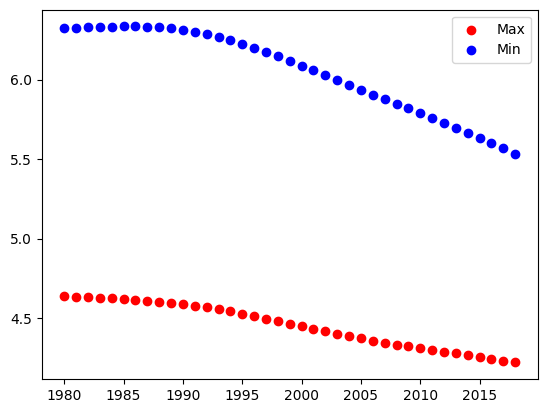

In [51]:
x = df_hungary_min_max_hungary_year_men['Year']
y1 = df_hungary_min_max_hungary_year_men['min chol level']
y2 = df_hungary_min_max_hungary_year_men['max chol level']

plt.scatter(x, y1, color = 'red', label = 'Max')
plt.scatter(x, y2, color = 'blue', label = 'Min')
plt.legend()
plt.show()